# The Price is Right

Today we build a more complex solution for estimating prices of goods.

1. Day 2.0 notebook: create a RAG database with our 400,000 training data
2. Day 2.1 notebook: visualize in 2D
3. Day 2.2 notebook: visualize in 3D
4. Day 2.3 notebook: build and test a RAG pipeline with GPT-4o-mini
5. Day 2.4 notebook: (a) bring back our Random Forest pricer (b) Create a Ensemble pricer that allows contributions from all the pricers

Phew! That's a lot to get through in one day!

## PLEASE NOTE:

We already have a very powerful product estimator with our proprietary, fine-tuned LLM. Most people would be very satisfied with that! The main reason we're adding these extra steps is to deepen your expertise with RAG and with Agentic workflows.

## Finishing off with Random Forests & Ensemble

In [1]:
# imports

import os
from tqdm import tqdm
from dotenv import load_dotenv
import numpy as np
import pickle
import chromadb

import sys
sys.path.append('../week6') 
from testing import Tester

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
import joblib


In [2]:
# CONSTANTS

QUESTION = "How much does this cost to the nearest dollar?\n\n"
DB = "products_vectorstore"

In [3]:
# environment

load_dotenv(override=True)
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY', 'your-key-if-not-using-env')
os.environ['HF_TOKEN'] = os.getenv('HF_TOKEN', 'your-key-if-not-using-env')

In [4]:
# Load in the test pickle file:

with open('../week6/test_lite.pkl', 'rb') as file:
    test = pickle.load(file)

In [5]:
client = chromadb.PersistentClient(path=DB)
collection = client.get_or_create_collection('products')

In [6]:
result = collection.get(include=['embeddings', 'documents', 'metadatas'])
vectors = np.array(result['embeddings'])
documents = result['documents']
prices = [metadata['price'] for metadata in result['metadatas']]

# Random Forest

We will now train a Random Forest model.

Can you spot the difference from what we did in Week 6? In week 6 we used the word2vec model to form vectors; this time we'll use the vectors we already have in Chroma, from the SentenceTransformer model.

In [7]:
# This next line takes an hour on my M1 Mac!

# rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
# rf_model = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=2)
# rf_model = RandomForestRegressor(
#     n_estimators=30,        # 更少的樹
#     max_depth=10,           # 限制每棵樹的深度
#     min_samples_split=10,   # 防止過擬合
#     n_jobs=4,               # 僅使用 2 個 CPU 執行緒
#     random_state=42
# )
rf_model = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=4)
rf_model.fit(vectors, prices)

RandomForestRegressor(max_depth=10, n_estimators=50, n_jobs=4, random_state=42)

In [8]:
# Save the model to a file

joblib.dump(rf_model, 'random_forest_model.pkl')

['random_forest_model.pkl']

In [9]:
# Load it back in again

rf_model = joblib.load('random_forest_model.pkl')

In [10]:
print(f"Rf_model length: {len(rf_model)}")

Rf_model length: 50


In [11]:
from agents.specialist_agent import SpecialistAgent
from agents.frontier_agent import FrontierAgent
from agents.random_forest_agent import RandomForestAgent

In [12]:
specialist = SpecialistAgent()
frontier = FrontierAgent(collection)
random_forest = RandomForestAgent()

In [13]:
def description(item):
    return item.prompt.split("to the nearest dollar?\n\n")[1].split("\n\nPrice is $")[0]

In [14]:
def rf(item):
    return random_forest.price(description(item))

Process status: 10% | Hits Rate so far: 52.0%
Process status: 20% | Hits Rate so far: 58.0%
Process status: 30% | Hits Rate so far: 57.3%
Process status: 40% | Hits Rate so far: 56.0%
Process status: 50% | Hits Rate so far: 56.0%
Process status: 60% | Hits Rate so far: 58.7%
Process status: 70% | Hits Rate so far: 59.4%
Process status: 80% | Hits Rate so far: 58.5%
Process status: 90% | Hits Rate so far: 59.1%
Process status: 100% | Hits Rate so far: 57.6%


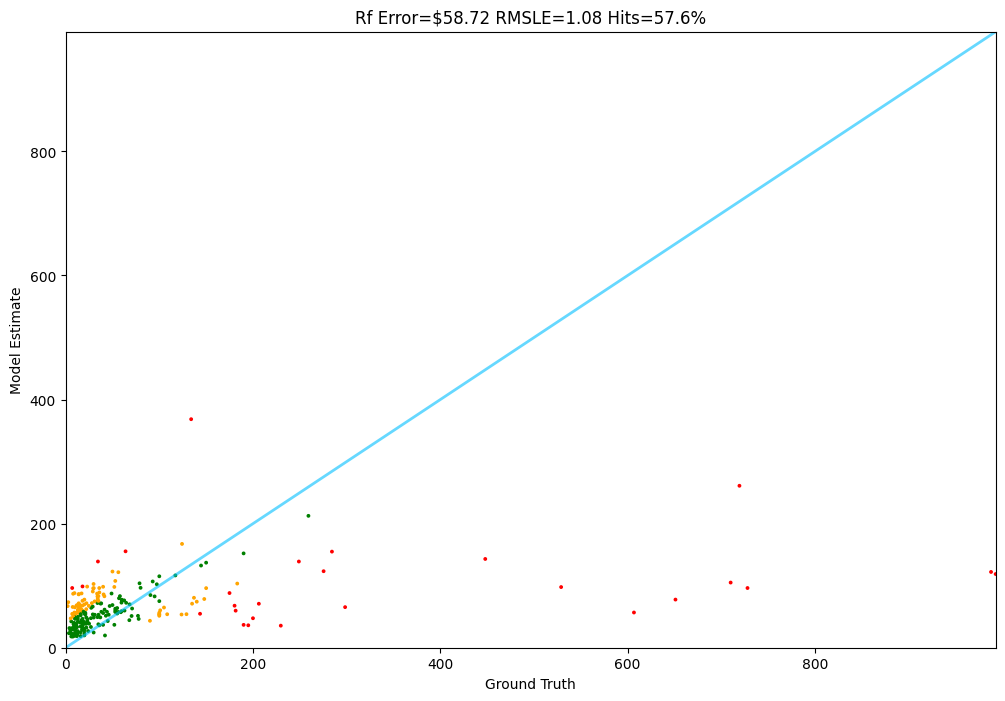

In [15]:
Tester.test(rf, test)

In [16]:
product = "Quadcast HyperX condenser mic for high quality audio for podcasting"

In [17]:
print(specialist.price(product))
print(frontier.price(product))
print(random_forest.price(product))

60.0
139.99
57.19243615648277


In [18]:
specialists = []
frontiers = []
random_forests = []
prices = []
for item in tqdm(test[1000:1250]):
    text = description(item)
    specialists.append(specialist.price(text))
    frontiers.append(frontier.price(text))
    random_forests.append(random_forest.price(text))
    prices.append(item.price)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 250/250 [35:16<00:00,  8.47s/it]


In [19]:
print (f"Prices length: {len(prices)}")
print (prices[0])

Prices length: 250
163.19


In [20]:
mins = [min(s,f,r) for s,f,r in zip(specialists, frontiers, random_forests)]
maxes = [max(s,f,r) for s,f,r in zip(specialists, frontiers, random_forests)]

X = pd.DataFrame({
    'Specialist': specialists,
    'Frontier': frontiers,
    'RandomForest': random_forests,
    'Min': mins,
    'Max': maxes,
})

# Convert y to a Series
y = pd.Series(prices)

In [21]:
# Train a Linear Regression
np.random.seed(42)

lr = LinearRegression()
lr.fit(X, y)

feature_columns = X.columns.tolist()

for feature, coef in zip(feature_columns, lr.coef_):
    print(f"{feature}: {coef:.2f}")
print(f"Intercept={lr.intercept_:.2f}")

Specialist: 1.39
Frontier: 1.40
RandomForest: 1.35
Min: -2.19
Max: -0.97
Intercept=-12.21


In [22]:
joblib.dump(lr, 'ensemble_model.pkl')

['ensemble_model.pkl']

In [23]:
es_model = joblib.load('ensemble_model.pkl')
print(type(es_model))
print(f"模型特徵數: {len(es_model.coef_)}")
print(f"模型係數: {es_model.coef_}")
print(f"模型截距: {es_model.intercept_}")
print(f"模型的特徵名稱: {es_model.feature_names_in_}")

<class 'sklearn.linear_model._base.LinearRegression'>
模型特徵數: 5
模型係數: [ 1.39087522  1.40056811  1.35415725 -2.18910508 -0.96995566]
模型截距: -12.21331141866954
模型的特徵名稱: ['Specialist' 'Frontier' 'RandomForest' 'Min' 'Max']


# ensemble.price Formula

你提供了新的模型輸入值：

| 特徵名稱         | 值        |
| ------------ | -------- |
| Specialist   | 60.0000  | 1.39087522
| Frontier     | 139.9900 | 1.40056811
| RandomForest | 57.19  | 1.35415725 
| Min          | 57.19  | -2.18910508
| Max          | 139.9900 | -0.96995566

---

## ✅ 使用模型係數與截距 + ✏️ 代入數值計算：

```python
= 1.39087522 × 60 (Specialist)
+ 1.40056811 × 139.99 (Frontier)
+ 1.35415725 × 57.19 (RandomForest)
- 2.18910508 × 57.19 (Min)
- 0.96995566 × 139.99 (Max)
- 12.2133 (Intercept)
```

---

### ✅ 加總結果：

```text
price ≈ 83.77
```

---


In [24]:
from agents.ensemble_agent import EnsembleAgent
ensemble = EnsembleAgent(collection)

In [25]:
ensemble.price(product)

83.76793732134936

In [26]:
def ensemble_pricer(item):
    return max(0,ensemble.price(description(item)))

Process status: 10% | Hits Rate so far: 100.0%
Process status: 20% | Hits Rate so far: 96.0%
Process status: 30% | Hits Rate so far: 89.3%
Process status: 40% | Hits Rate so far: 86.0%
Process status: 50% | Hits Rate so far: 86.4%
Process status: 60% | Hits Rate so far: 84.0%
Process status: 70% | Hits Rate so far: 84.6%
Process status: 80% | Hits Rate so far: 82.0%
Process status: 90% | Hits Rate so far: 82.2%
Process status: 100% | Hits Rate so far: 80.4%


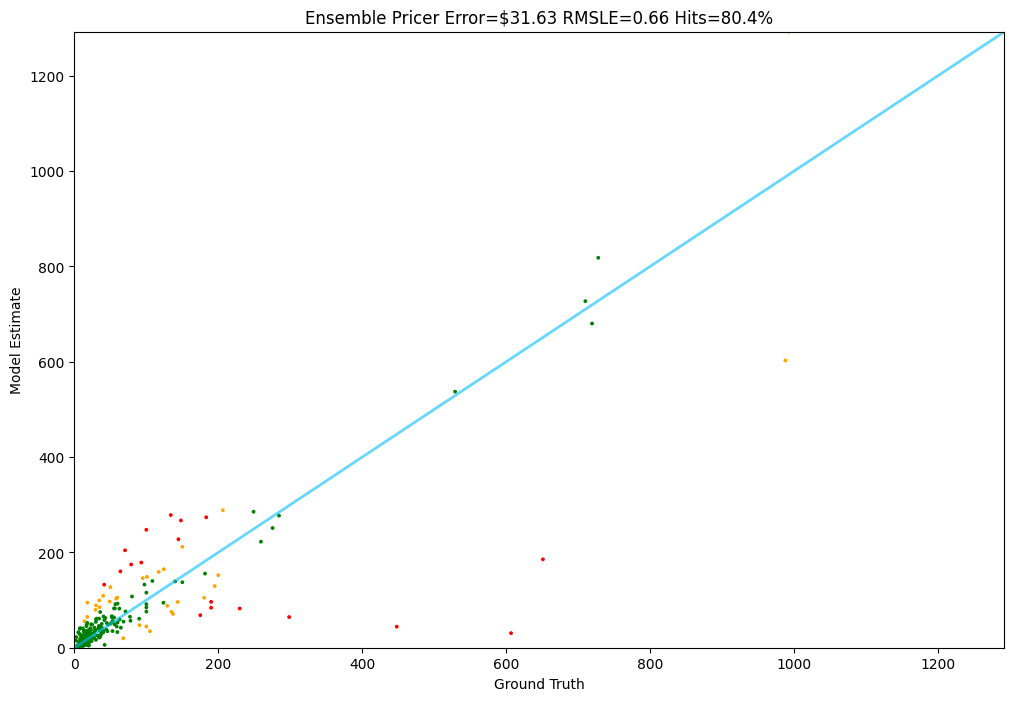

In [27]:
Tester.test(ensemble_pricer, test)

# WHAT A DAY!

We got so much done - a Fronter RAG pipeline, a Random Forest model using transformer-based encodings, and an Ensemble model.

You can do better, for sure!

Tweak this, and try adding components into the ensemble, to beat my performance.